In [1]:
import warnings
warnings.filterwarnings("ignore")
from test_multicommodity import test_main, create_forcing, plot_result
from mcopt_misc import plot_network, run_mcopt
import sys
sys.path.append('../src/')
import numpy as np
from mcopt import McOpt, paris_topology
from typing import Dict, List, Tuple
import networkx as nx
import matplotlib.pyplot as plt

np.random.seed(42)

In [2]:
def constrcut_mcopt(beta: float=1, n=30, alpha=1, betaw=0.25, L=1.0):
    waxman_config = {"n": n, "alpha": alpha, "beta": betaw, "L": L}
    method, coupling, museed, pflux, rho = "synth", "l1", 0, beta, 0.0   
    time_step, tot_time, relax_linsys, tau_cond_dyn, tau_cost_dyn = 0.5, 10000, 1.0e-5, 1.0e-1, 1.0e-1
    tau_cond_opt, tau_cost_opt = 1.0e-1, 1.0e-1
    VERBOSE = False
    mcopt = McOpt("synth", coupling, museed, pflux, VERBOSE, rho, relax_linsys, tau_cond_dyn, tau_cost_dyn, time_step, tot_time, tau_cond_opt, tau_cost_opt, waxman_config)
    mcopt.ot_setup()
    return mcopt

def compare_mcopt_admk(beta: float=1, n=30, alpha=1, betaw=0.25, L=1.0):
    mcopt = constrcut_mcopt(beta, n, alpha, betaw, L)
    forcing, conductivity_mcopt = run_mcopt(mcopt)
    topo, weights, forcing_ = mcopt.export_setup()
    potentials, conductivity_admk, potentials_admk = test_main(topo.copy(), weights, len(forcing_[0]), forcing_, beta=beta, max_iter=25)
    plot_network(mcopt.g, forcing, conductivity_mcopt, conductivity_admk)
    return mcopt, mcopt.g, forcing_, conductivity_mcopt

def coordinate_to_key(coord):
    y = int(coord[1] / (np.sqrt(3) / 2) + 0.5)
    x = round(coord[0]) if y % 2 == 0 else round(coord[0] - 0.5)
    return (x, y)


def discretize_triangular(mcopt: McOpt, graph: nx.Graph, forcing: List[np.ndarray], mesh_size=17, beta=1, max_iter=30, n=30, alpha=1, betaw=0.25, L=1.0):
    X_SCALE, Y_SCALE = mesh_size - 1, (mesh_size - 1) * (np.sqrt(3) / 2)
    mesh = nx.triangular_lattice_graph(mesh_size, mesh_size * 2)
    num_commodity = len(mesh.nodes()) 
    nodes_list = list(mesh.nodes())          
    key_to_index = {key: idx for idx, key in enumerate(nodes_list)}
    idx_to_key = {idx: key for key, idx in key_to_index.items()}

    forcing_grid = [np.zeros(num_commodity) for _ in range(len(mesh.nodes()))]
    node_to_index = {}
    for node in graph.nodes:
        raw_pos = (graph.nodes[node]["pos"][0] * X_SCALE, graph.nodes[node]["pos"][1] * Y_SCALE)
        graph.nodes[node]["pos"] = raw_pos
        key = coordinate_to_key(raw_pos)
        index = key_to_index[key]
        node_to_index[node] = index
    for node in graph.nodes:
        for comm in range(len(graph.nodes)):
            forcing_grid[node_to_index[comm]][node_to_index[node]] += forcing[node][comm]
    for node in mesh.nodes():
        mesh.nodes[node]["amplitude"] = np.linalg.norm(forcing_grid[key_to_index[node]])
    edge_lists = np.array([list((key_to_index[e[0]], key_to_index[e[1]])) for e in mesh.edges()])
    weights = np.ones_like(edge_lists[:, 0]) + 0.05 * np.random.rand(*(edge_lists[:,0].shape))
    potentials, conductivity_admk, energy = test_main(edge_lists, weights, num_commodity, forcing_grid, beta=beta, max_iter=max_iter)
    plt.show()
    pos = {n: (n[0], n[1]) for n in mesh.nodes()}
    nx.draw_networkx_edges(mesh, pos=pos, width=np.array(conductivity_admk) * 0.15,  edge_color='C0', style='solid')
    amps = [mesh.nodes[n]['amplitude']  for n in mesh.nodes()]
    
    nx.draw_networkx_nodes(mesh, pos=pos, node_size=amps, node_color='orange')
    plt.title(f"Triangular Lattice Approximation with Waxman Parameter: n = {n}, alpha = {alpha}, beta = {betaw}, L = {L} | Energy = {energy}")
    plt.show()

    mesh_flattened = nx.Graph()
    mesh_flattened.add_edges_from(edge_lists)
    print(edge_lists[0:10])
    print([list((e[0], e[1])) for e in mesh_flattened.edges()][0:10])
    mcopt.ot_reset(mesh_flattened, weights, np.vstack(forcing_grid))
    forcing_on_grid, conductivity_mcopt_on_grid = run_mcopt(mcopt)
    print(forcing_on_grid)
    plt.show()
    nx.draw_networkx_edges(mesh, pos=pos, width=np.array(conductivity_mcopt_on_grid) * 0.05,  edge_color='C0', style='solid')
    nx.draw_networkx_nodes(mesh, pos=pos, node_size=amps, node_color='orange')
    plt.title(f"Triangular Lattice Approximation with McOpt")
    plt.show()
    return mesh, conductivity_admk, energy

In [3]:
def waxman_triangular_lattice_wasserstein(mesh_size=17):
    mcopt, graph_mcopt, forcing, conductivity_mcopt = compare_mcopt_admk()
    graph_admk, conductivity_admk, energy_admk = discretize_triangular(mcopt, graph_mcopt, forcing, mesh_size=mesh_size)
    Num_node_mcopt, Num_edge_mcopt, Num_node_admk, Num_edge_admk = len(graph_mcopt.nodes()), len(graph_mcopt.edges()), len(graph_admk.nodes()), len(graph_admk.edges())
    key_to_index = {key: idx for idx, key in enumerate(graph_admk.nodes())}
    
    norm_conductivity_mcopt, norm_conductivity_admk = conductivity_mcopt / np.linalg.norm(conductivity_mcopt), conductivity_admk / np.linalg.norm(conductivity_admk)
    index = 0
    for n, attrs in graph_mcopt.nodes(data=True): attrs["type"] = "mcopt"
    for u, v, attrs in graph_mcopt.edges(data=True): 
        attrs["type"] = "mcopt"
        attrs["conductivity"] = norm_conductivity_mcopt[index]
        index += 1
    
    index = 0
    for n, attrs in graph_admk.nodes(data=True): attrs["type"] = "admk"
    for u, v, attrs in graph_admk.edges(data=True): 
        attrs["type"] = "admk"
        attrs["conductivity"] = norm_conductivity_admk[index]
        index += 1
    
    graph_union = nx.disjoint_union(graph_mcopt, graph_admk)
    for node_mcopt in graph_union.nodes():
        graph_union.nodes[node_mcopt]["force"] = 0
        if node_mcopt < Num_node_mcopt:
            closest_node_admk = key_to_index[coordinate_to_key(graph_union.nodes[node_mcopt]["pos"])] + Num_node_mcopt
            graph_union.nodes[node_mcopt]["close"], graph_union.nodes[closest_node_admk]["close"] = closest_node_admk, node_mcopt
            graph_union.nodes[node_mcopt]["force"], graph_union.nodes[closest_node_admk]["force"] = 1, -1
            graph_union.add_edge(node_mcopt, closest_node_admk, type="mixed", conductivity=1)
    
    pos = nx.get_node_attributes(graph_union, 'pos')
    colors_node = list(map(lambda kv: "red" if kv[1] == "mcopt" else "blue", nx.get_node_attributes(graph_union, "type").items()))
    colors_edge = list(map(lambda kv: "green" if kv[1] == "mcopt" else ("orange" if kv[1] == "mixed" else "black"), nx.get_edge_attributes(graph_union, "type").items()))
    edge_mcopt_yes, edge_admk_yes, edge_mixed_yes = list(map(lambda kv: kv[1] == "mcopt", nx.get_edge_attributes(graph_union, "type").items())), list(map(lambda kv: kv[1] == "admk", nx.get_edge_attributes(graph_union, "type").items())), list(map(lambda kv: kv[1] == "mixed", nx.get_edge_attributes(graph_union, "type").items()))
    nx.draw_networkx_nodes(graph_union, pos, node_color=colors_node, node_size=10)
    nx.draw_networkx_edges(graph_union, pos, edge_color=colors_edge, width=np.array(list(nx.get_edge_attributes(graph_union, "conductivity").values())) * 5 * edge_mixed_yes)
    plt.show()

    nx.draw_networkx_nodes(graph_union, pos, node_color=colors_node, node_size=10)
    nx.draw_networkx_edges(graph_union, pos, edge_color=colors_edge, width=np.array(list(nx.get_edge_attributes(graph_union, "conductivity").values())) * 30 * edge_admk_yes)
    plt.show()

    nx.draw_networkx_nodes(graph_union, pos, node_color=colors_node, node_size=10)
    nx.draw_networkx_edges(graph_union, pos, edge_color=colors_edge, width=np.array(list(nx.get_edge_attributes(graph_union, "conductivity").values())) * 10 * edge_mcopt_yes)
    plt.show()

    num_commidity = len(graph_mcopt.nodes())
    forcing = [np.zeros(len(graph_union.nodes())) for _ in range(num_commidity)]
    print(len(forcing))
    for node, attrs in graph_union.nodes(data=True):
        if attrs["force"] == 1: 
            forcing[node][node] += 1 
            forcing[node][attrs["close"]] -= 1
    edge_lists = np.array([list((e[0], e[1])) for e in graph_union.edges()])
    weights = np.minimum(np.array(list(nx.get_edge_attributes(graph_union, "conductivity").values())) + 1e-5, 1)
    potentials, conductivity_similarity, energy_optimal = test_main(edge_lists, weights, num_commidity, forcing, max_iter=20)
    pos = nx.get_node_attributes(graph_union, "pos")
    plt.show()
    nx.draw_networkx_edges(graph_union, pos=pos, width=np.array(conductivity_similarity) * 0.2,  edge_color='C0', style='solid')
    nx.draw_networkx_nodes(graph_union, pos=pos, node_size=1, node_color='orange')
    plt.title(f"Similarity | Energy = {energy_optimal}")
    plt.show()
    return energy_optimal

In [4]:
#waxman_triangular_lattice_wasserstein(mesh_size=13)

In [5]:
#waxman_triangular_lattice_wasserstein(mesh_size=8)

* graph topology construction
* running [dynamics]
stiff_relax shape: (30, 30) | self.forcing: (30, 30)
	convergence achieved [dynamics]
* export fluxes
* export cost
MinNorm Setup: n_row: 30, n_col: 76, self.n_rhs: 30
init signature: (self, tol_optimization=0.001, tol_constraint=1e-08, method='explicit_tdens', max_iter=200, max_restart=5, method_ctrl=None, verbose=0, log=0, log_file='admk.log', beta=1, log_print: bool = True)
ierr=0 avg_it=0010 max(res)=7.4e-09 max(pres)=6.4e-07
   1.31e+01<=UPDATE<=2.04e+03, deltat=1.96e-03
ierr=0 avg_it=0010 max(res)=9.9e-09 max(pres)=9.6e-07
it=1 var=1.87e+02
   8.75e+00<=UPDATE<=9.64e+02, deltat=2.01e-02
ierr=0 avg_it=0012 max(res)=8.7e-09 max(pres)=7.5e-07
it=2 var=3.52e+01
   1.75e+00<=UPDATE<=2.60e+02, deltat=1.00e-01
ierr=0 avg_it=0012 max(res)=9.6e-09 max(pres)=6.6e-07
it=3 var=5.36e+00
   -1.18e+00<=UPDATE<=9.83e+01, deltat=1.00e-01
ierr=0 avg_it=0011 max(res)=9.7e-09 max(pres)=8.1e-07
it=4 var=1.65e+00
   -1.63e+00<=UPDATE<=6.69e+01, deltat

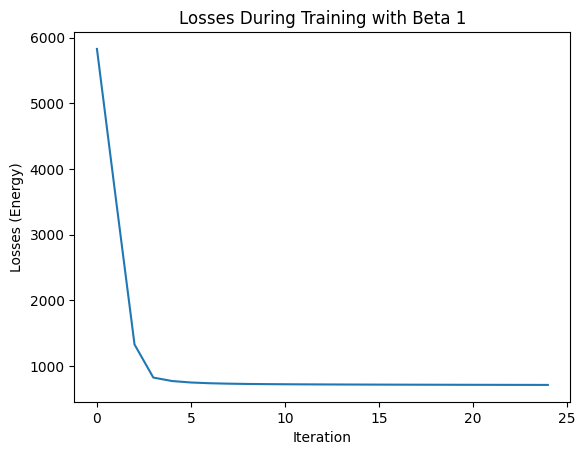

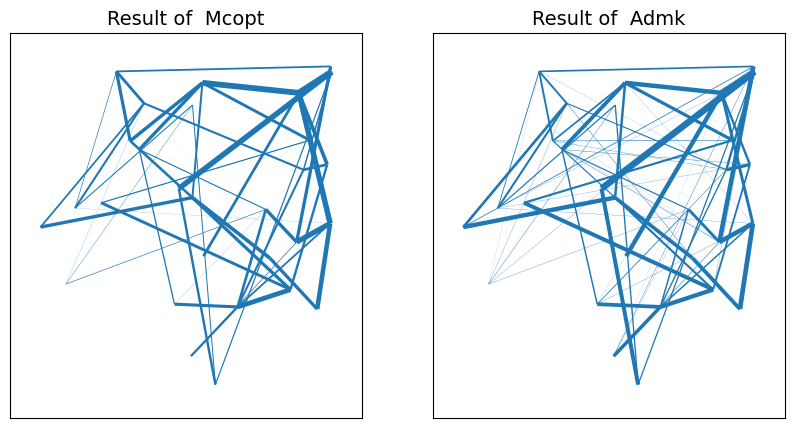

MinNorm Setup: n_row: 324, n_col: 901, self.n_rhs: 324
Rhs9 is not balanced 7.0E-03
Rhs82 is not balanced 1.1E-02
Rhs86 is not balanced 4.9E-03
Rhs120 is not balanced 3.6E-03
Rhs144 is not balanced 1.6E-02
Rhs165 is not balanced 3.8E-03
Rhs187 is not balanced 1.3E-02
Rhs211 is not balanced 9.3E-03
Rhs278 is not balanced 1.4E-02
Rhs303 is not balanced 1.5E-02
Error in inputs at time t= 0.0
init signature: (self, tol_optimization=0.001, tol_constraint=1e-08, method='explicit_tdens', max_iter=200, max_restart=5, method_ctrl=None, verbose=0, log=0, log_file='admk.log', beta=1, log_print: bool = True)
ierr=0 avg_it=0004 max(res)=9.9e-09 max(pres)=8.1e-07
   -2.00e+00<=UPDATE<=5.75e+02, deltat=6.96e-03
ierr=0 avg_it=0002 max(res)=9.9e-09 max(pres)=9.4e-07
it=1 var=2.60e+01
   -1.99e+00<=UPDATE<=2.00e+02, deltat=7.00e-02
ierr=0 avg_it=0004 max(res)=9.8e-09 max(pres)=7.8e-07
it=2 var=8.29e+00
   -1.85e+00<=UPDATE<=5.94e+01, deltat=1.00e-01
ierr=0 avg_it=0003 max(res)=1.0e-08 max(pres)=9.8e-07


In [ ]:
waxman_triangular_lattice_wasserstein(mesh_size=17)